In [1]:
import numpy as np

import pandas as pd

import tubesml as tml

from source.report import report_victory, yearly_wrapper, _point_to_proba
from source.validate import random_split, yearly_split

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, brier_score_loss
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
train_dict = {}
test_dict = {}

for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb"]:
    df = pd.read_csv(f"data/results/women_train_{model}.csv")
    df = df.rename(columns={"oof_prob": f"{model}_pred"})
    df = df[["Season", "ID", "target", f"{model}_pred"] + [c for c in df if "stage" in c]]
    df[[c for c in df if "stage" in c]] = df[[c for c in df if "stage" in c]].astype(int)
    train_dict[model] = df
    df = pd.read_csv(f"data/results/women_test_{model}.csv")
    df = df.rename(columns={"pred_prob": f"{model}_pred"})
    df = df[["Season", "ID", "target", f"{model}_pred"] + [c for c in df if "stage" in c]]
    df[[c for c in df if "stage" in c]] = df[[c for c in df if "stage" in c]].astype(int)
    test_dict[model] = df

In [3]:
train_dict["lasso"].head()

,Season,ID,target,lasso_pred,stage_Round1,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible
0,2015,2015_3449_3274,0,0.728170,1,0,0,0,0,0,0
1,2012,2012_3210_3357,1,0.958096,1,0,0,0,0,0,0
2,2024,2024_3333_3186,1,0.914465,1,0,0,0,0,0,0
3,2018,2018_3397_3251,1,0.900377,1,0,0,0,0,0,0
4,2016,2016_3333_3177,1,0.466859,0,0,1,0,0,0,0


In [4]:
df_train = train_dict["lasso"].copy()
df_test = test_dict["lasso"].copy()

for model in ["lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb"]:

    df_train = pd.merge(df_train, train_dict[model][["ID", f"{model}_pred"]], how="left", on="ID")
    df_test = pd.merge(df_test, test_dict[model][["ID", f"{model}_pred"]], how="left", on="ID")

df_train["mean_pred"] = df_train[['lasso_pred', 'logit_pred']].mean(axis=1)  # from below test
df_test["mean_pred"] = df_test[['lasso_pred', 'logit_pred']].mean(axis=1)

In [5]:
df_train.head()

,Season,ID,target,lasso_pred,stage_Round1,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,lgb_class_pred,lgb_pred,logit_pred,ridge_pred,xgb_class_pred,xgb_pred,mean_pred
0,2015,2015_3449_3274,0,0.728170,1,0,0,0,0,0,0,0.688502,0.674724,0.722619,0.702297,0.742488,0.817311,0.725394
1,2012,2012_3210_3357,1,0.958096,1,0,0,0,0,0,0,0.956622,0.909180,0.985291,0.908912,0.962349,0.815755,0.971693
2,2024,2024_3333_3186,1,0.914465,1,0,0,0,0,0,0,0.935924,0.876028,0.947897,0.898736,0.825596,0.821897,0.931181
3,2018,2018_3397_3251,1,0.900377,1,0,0,0,0,0,0,0.907843,0.907223,0.937438,0.886646,0.892870,0.788511,0.918908
4,2016,2016_3333_3177,1,0.466859,0,0,1,0,0,0,0,0.497272,0.499882,0.515940,0.434883,0.539884,0.510815,0.491399


In [6]:
df_test.head()

,Season,ID,target,lasso_pred,stage_Round1,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,lgb_class_pred,lgb_pred,logit_pred,ridge_pred,xgb_class_pred,xgb_pred,mean_pred
0,2015,2015_3173_3235,1,0.708822,1,0,0,0,0,0,0,0.691417,0.640248,0.730850,0.739347,0.702000,0.785475,0.719836
1,2018,2018_3323_3169,1,0.983476,1,0,0,0,0,0,0,0.942065,0.921092,0.988741,0.908912,0.926517,0.815755,0.986109
2,2015,2015_3346_3328,0,0.333494,1,0,0,0,0,0,0,0.399498,0.357386,0.135217,0.304893,0.334969,0.452784,0.234356
3,2018,2018_3311_3280,0,0.010000,1,0,0,0,0,0,0,0.042330,0.052828,0.003098,0.090610,0.044385,0.168492,0.006549
4,2022,2022_3199_3283,0,0.540159,0,0,0,0,0,0,1,0.478975,0.490572,0.647246,0.579653,0.504215,0.513770,0.593702


array([[<Axes: title={'center': 'lasso_pred'}>,
        <Axes: title={'center': 'lgb_class_pred'}>,
        <Axes: title={'center': 'lgb_pred'}>],
       [<Axes: title={'center': 'logit_pred'}>,
        <Axes: title={'center': 'ridge_pred'}>,
        <Axes: title={'center': 'xgb_class_pred'}>],
       [<Axes: title={'center': 'xgb_pred'}>,
        <Axes: title={'center': 'mean_pred'}>, <Axes: >]], dtype=object)

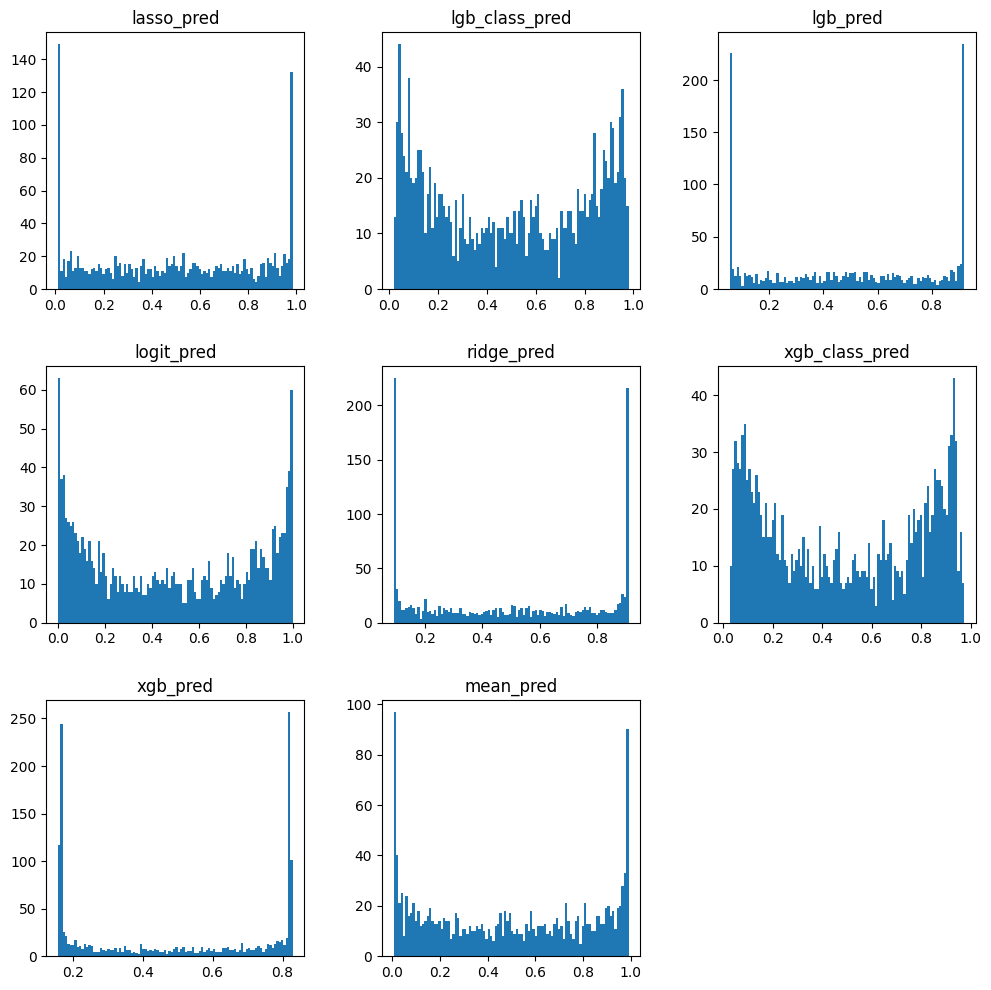

In [7]:
df_train[[c for c in df_train if "pred" in c]].hist(bins=100, grid=False, figsize=(12,12))

array([[<Axes: title={'center': 'lasso_pred'}>,
        <Axes: title={'center': 'lgb_class_pred'}>,
        <Axes: title={'center': 'lgb_pred'}>],
       [<Axes: title={'center': 'logit_pred'}>,
        <Axes: title={'center': 'ridge_pred'}>,
        <Axes: title={'center': 'xgb_class_pred'}>],
       [<Axes: title={'center': 'xgb_pred'}>,
        <Axes: title={'center': 'mean_pred'}>, <Axes: >]], dtype=object)

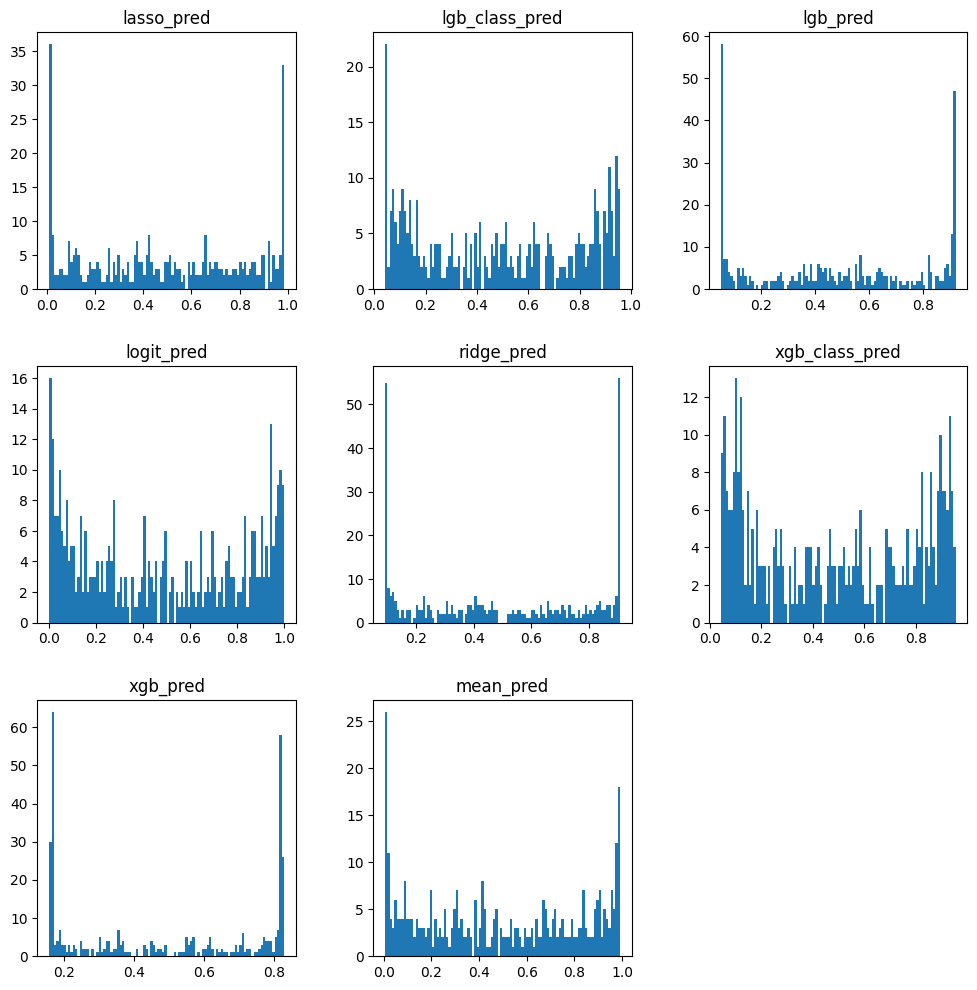

In [8]:
df_test[[c for c in df_test if "pred" in c]].hist(bins=100, grid=False, figsize=(12,12))

In [9]:
for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb", "mean"]:
    print(model)
    print(f"Accuracy train: {accuracy_score(y_true=df_train["target"], y_pred=df_train[f'{model}_pred'] > 0.5)}")
    print(f"Accuracy test: {accuracy_score(y_true=df_test["target"], y_pred=df_test[f'{model}_pred'] > 0.5)}")
    print(f"Brier train: {brier_score_loss(y_true=df_train["target"], y_prob=df_train[f'{model}_pred'])}")
    print(f"Brier test: {brier_score_loss(y_true=df_test["target"], y_prob=df_test[f'{model}_pred'])}")

lasso
Accuracy train: 0.8031496062992126
Accuracy test: 0.8036649214659686
Brier train: 0.13930602509216833
Brier test: 0.13328711097856336
lgb_class
Accuracy train: 0.7887139107611548
Accuracy test: 0.7905759162303665
Brier train: 0.14519227036330337
Brier test: 0.14160650422607698
lgb
Accuracy train: 0.7979002624671916
Accuracy test: 0.7958115183246073
Brier train: 0.14391164840040377
Brier test: 0.1388942343153507
logit
Accuracy train: 0.800524934383202
Accuracy test: 0.8219895287958116
Brier train: 0.14020192935271614
Brier test: 0.13213920528777273
ridge
Accuracy train: 0.8057742782152231
Accuracy test: 0.8115183246073299
Brier train: 0.14108322391048417
Brier test: 0.13401671153089448
xgb_class
Accuracy train: 0.7926509186351706
Accuracy test: 0.8010471204188482
Brier train: 0.14629790597653092
Brier test: 0.1428603491512395
xgb
Accuracy train: 0.8011811023622047
Accuracy test: 0.7905759162303665
Brier train: 0.1512817350847114
Brier test: 0.14738072133954722
mean
Accuracy train:

# Per stage

In [10]:
res_train = pd.DataFrame()
res_test = pd.DataFrame()

for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb", "mean"]:
    model_acc_train = []
    model_brier_train = []
    model_acc_test = []
    model_brier_test = []

    for stage in ["Round1", "Round2", "Round3", "Round4", "finalfour", "final"]:
        tmp_train = df_train[df_train[f"stage_{stage}"] == 1]
        tmp_test = df_test[df_test[f"stage_{stage}"] == 1]
        model_acc_train.append(accuracy_score(y_true=tmp_train["target"], y_pred=tmp_train[f'{model}_pred'] > 0.5))
        model_acc_test.append(accuracy_score(y_true=tmp_test["target"], y_pred=tmp_test[f'{model}_pred'] > 0.5))

        model_brier_train.append(brier_score_loss(y_true=tmp_train["target"], y_prob=tmp_train[f'{model}_pred']))
        model_brier_test.append(brier_score_loss(y_true=tmp_test["target"], y_prob=tmp_test[f'{model}_pred']))

    res_train[f"{model}_accuracy"] = model_acc_train
    res_train[f"{model}_brier"] = model_brier_train
    res_test[f"{model}_accuracy"] = model_acc_test
    res_test[f"{model}_brier"] = model_brier_test

res_train.index = ["Round1", "Round2", "Round3", "Round4", "finalfour", "final"]
res_test.index = ["Round1", "Round2", "Round3", "Round4", "finalfour", "final"]

In [11]:
res_train[[c for c in res_train if "brier" in c]]

,lasso_brier,lgb_class_brier,lgb_brier,logit_brier,ridge_brier,xgb_class_brier,xgb_brier,mean_brier
Round1,0.114863,0.122552,0.119566,0.115422,0.118337,0.123068,0.131998,0.113627
Round2,0.155507,0.163820,0.163075,0.151138,0.154227,0.165058,0.167707,0.151939
Round3,0.160782,0.169224,0.157901,0.168125,0.164175,0.168533,0.159797,0.163064
Round4,0.169482,0.152697,0.188471,0.161817,0.167471,0.158845,0.184324,0.163667
finalfour,0.244211,0.243334,0.248385,0.272398,0.244868,0.258629,0.242270,0.255553
final,0.133686,0.116763,0.102609,0.159314,0.141694,0.106062,0.104203,0.144610


In [12]:
res_train[[c for c in res_train if "brier" in c]].rank(axis=1)

,lasso_brier,lgb_class_brier,lgb_brier,logit_brier,ridge_brier,xgb_class_brier,xgb_brier,mean_brier
Round1,2.0,6.0,5.0,3.0,4.0,7.0,8.0,1.0
Round2,4.0,6.0,5.0,1.0,3.0,7.0,8.0,2.0
Round3,3.0,8.0,1.0,6.0,5.0,7.0,2.0,4.0
Round4,6.0,1.0,8.0,3.0,5.0,2.0,7.0,4.0
finalfour,3.0,2.0,5.0,8.0,4.0,7.0,1.0,6.0
final,5.0,4.0,1.0,8.0,6.0,3.0,2.0,7.0


In [13]:
res_train[[c for c in res_train if "brier" in c]].rank(axis=1).mean()

lasso_brier        3.833333
lgb_class_brier    4.500000
lgb_brier          4.166667
logit_brier        4.833333
ridge_brier        4.500000
xgb_class_brier    5.500000
xgb_brier          4.666667
mean_brier         4.000000
dtype: float64

In [14]:
res_test[[c for c in res_train if "brier" in c]]

,lasso_brier,lgb_class_brier,lgb_brier,logit_brier,ridge_brier,xgb_class_brier,xgb_brier,mean_brier
Round1,0.103865,0.117260,0.110140,0.109373,0.106461,0.117787,0.128603,0.105370
Round2,0.156190,0.164443,0.163858,0.155545,0.158084,0.168301,0.166510,0.154731
Round3,0.145066,0.136012,0.138813,0.122185,0.141215,0.135174,0.135265,0.131795
Round4,0.180079,0.180781,0.198397,0.164879,0.179119,0.180579,0.185618,0.171469
finalfour,0.199065,0.227135,0.218113,0.184124,0.185216,0.230793,0.215069,0.190743
final,0.185302,0.083134,0.114487,0.242279,0.207741,0.096379,0.133603,0.212680


In [15]:
res_test[[c for c in res_train if "brier" in c]].rank(axis=1)

,lasso_brier,lgb_class_brier,lgb_brier,logit_brier,ridge_brier,xgb_class_brier,xgb_brier,mean_brier
Round1,1.0,6.0,5.0,4.0,3.0,7.0,8.0,2.0
Round2,3.0,6.0,5.0,2.0,4.0,8.0,7.0,1.0
Round3,8.0,5.0,6.0,1.0,7.0,3.0,4.0,2.0
Round4,4.0,6.0,8.0,1.0,3.0,5.0,7.0,2.0
finalfour,4.0,7.0,6.0,1.0,2.0,8.0,5.0,3.0
final,5.0,1.0,3.0,8.0,6.0,2.0,4.0,7.0


In [16]:
res_test[[c for c in res_train if "brier" in c]].rank(axis=1).mean()

lasso_brier        4.166667
lgb_class_brier    5.166667
lgb_brier          5.500000
logit_brier        2.833333
ridge_brier        4.166667
xgb_class_brier    5.500000
xgb_brier          5.833333
mean_brier         2.833333
dtype: float64

# Per prediction probability

In [17]:
for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb", "mean"]:
    bins = np.arange(0, 1.05, 0.05)  # 0, 0.05, 0.10, ..., 1.00

    labels = [f"{model}_{round(bins[i],2)}–{round(bins[i+1],2)}" for i in range(len(bins)-1)]

    df_train[f"{model}_bins"] = pd.cut(df_train[f"{model}_pred"], bins=bins, labels=labels, include_lowest=True)
    df_test[f"{model}_bins"] = pd.cut(df_test[f"{model}_pred"], bins=bins, labels=labels, include_lowest=True)

In [18]:
df_train.groupby("xgb_class_bins", observed=True)["target"].mean()

xgb_class_bins
xgb_class_0.0–0.05    0.017544
xgb_class_0.05–0.1    0.051613
xgb_class_0.1–0.15    0.071429
xgb_class_0.15–0.2    0.244444
xgb_class_0.2–0.25    0.290698
xgb_class_0.25–0.3    0.285714
xgb_class_0.3–0.35    0.383333
xgb_class_0.35–0.4    0.306122
xgb_class_0.4–0.45    0.395833
xgb_class_0.45–0.5    0.433962
xgb_class_0.5–0.55    0.551020
xgb_class_0.55–0.6    0.562500
xgb_class_0.6–0.65    0.679245
xgb_class_0.65–0.7    0.745455
xgb_class_0.7–0.75    0.549020
xgb_class_0.75–0.8    0.786517
xgb_class_0.8–0.85    0.764045
xgb_class_0.85–0.9    0.898438
xgb_class_0.9–0.95    0.955975
xgb_class_0.95–1.0    1.000000
Name: target, dtype: float64

In [19]:
df_train.groupby("mean_bins", observed=True)["target"].mean()

mean_bins
mean_0.0–0.05    0.005319
mean_0.05–0.1    0.055556
mean_0.1–0.15    0.216216
mean_0.15–0.2    0.186667
mean_0.2–0.25    0.253968
mean_0.25–0.3    0.271186
mean_0.3–0.35    0.226415
mean_0.35–0.4    0.370370
mean_0.4–0.45    0.380000
mean_0.45–0.5    0.445946
mean_0.5–0.55    0.640000
mean_0.55–0.6    0.678571
mean_0.6–0.65    0.677966
mean_0.65–0.7    0.603774
mean_0.7–0.75    0.731343
mean_0.75–0.8    0.777778
mean_0.8–0.85    0.785714
mean_0.85–0.9    0.797101
mean_0.9–0.95    0.934066
mean_0.95–1.0    0.988571
Name: target, dtype: float64

In [20]:
df_train[df_train["mean_pred"] > 0.7].groupby("logit_bins", observed=True)["target"].mean()

logit_bins
logit_0.6–0.65    0.500000
logit_0.65–0.7    0.500000
logit_0.7–0.75    0.789474
logit_0.75–0.8    0.756757
logit_0.8–0.85    0.807229
logit_0.85–0.9    0.807692
logit_0.9–0.95    0.891089
logit_0.95–1.0    0.983240
Name: target, dtype: float64

# Models

In [21]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True, predict_proba=True, regression=False)

    oof, pred, result_dict = cv_score.score()

    score = brier_score_loss(y_true=target, y_prob=oof)
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = brier_score_loss(y_true=test_target, y_prob=pred)
        print(f"Test score: {score}")
        tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    return oof, pred, result_dict

In [22]:
DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"] + [c for c in df_train if "bins" in c or "mean" in c]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

In [23]:
def pred_per_stage(data):
    df = data.copy()
    for c in ["stage_Round1", "stage_Round2", "stage_Round3", "stage_Round3", "stage_finalfour", "stage_final"]:
        for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb"]:
            df[f"{model}_{c}_keep"] = df[f"{model}_pred"] * df[c]

    return df[[c for c in df if "_keep" in c]]

OOF score: 0.15848622890629108
[23, 31, 20, 9, 12]


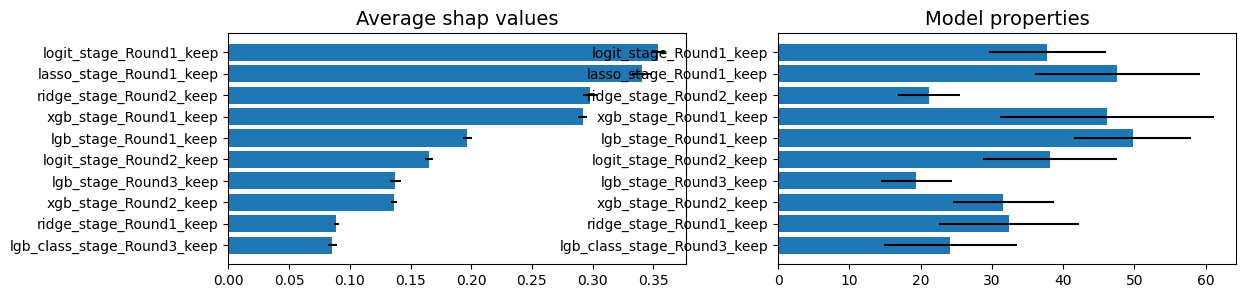

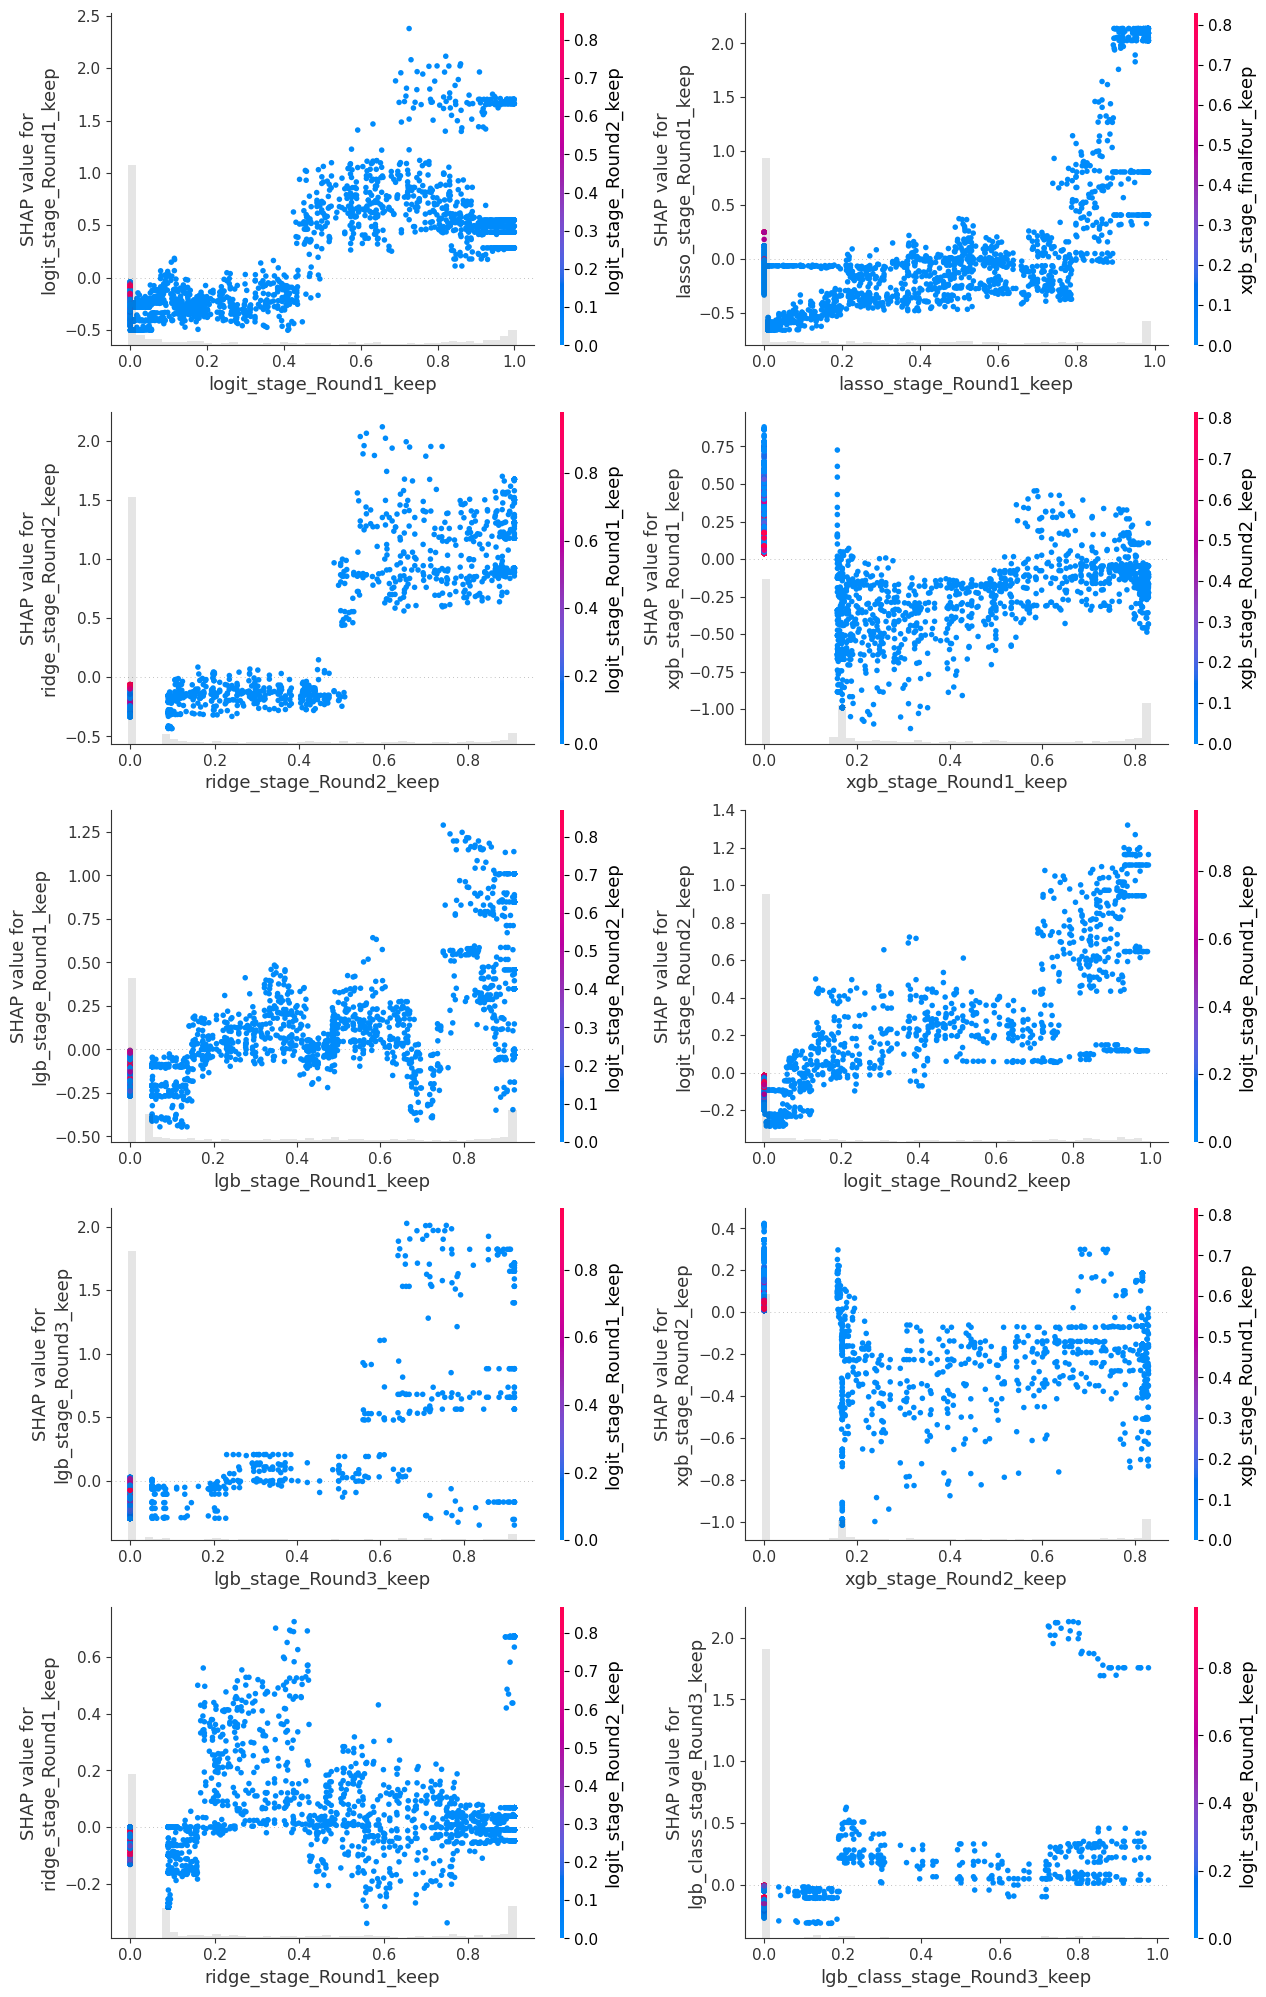

The feature delta_Seed is not in the provided data, it will be ignored


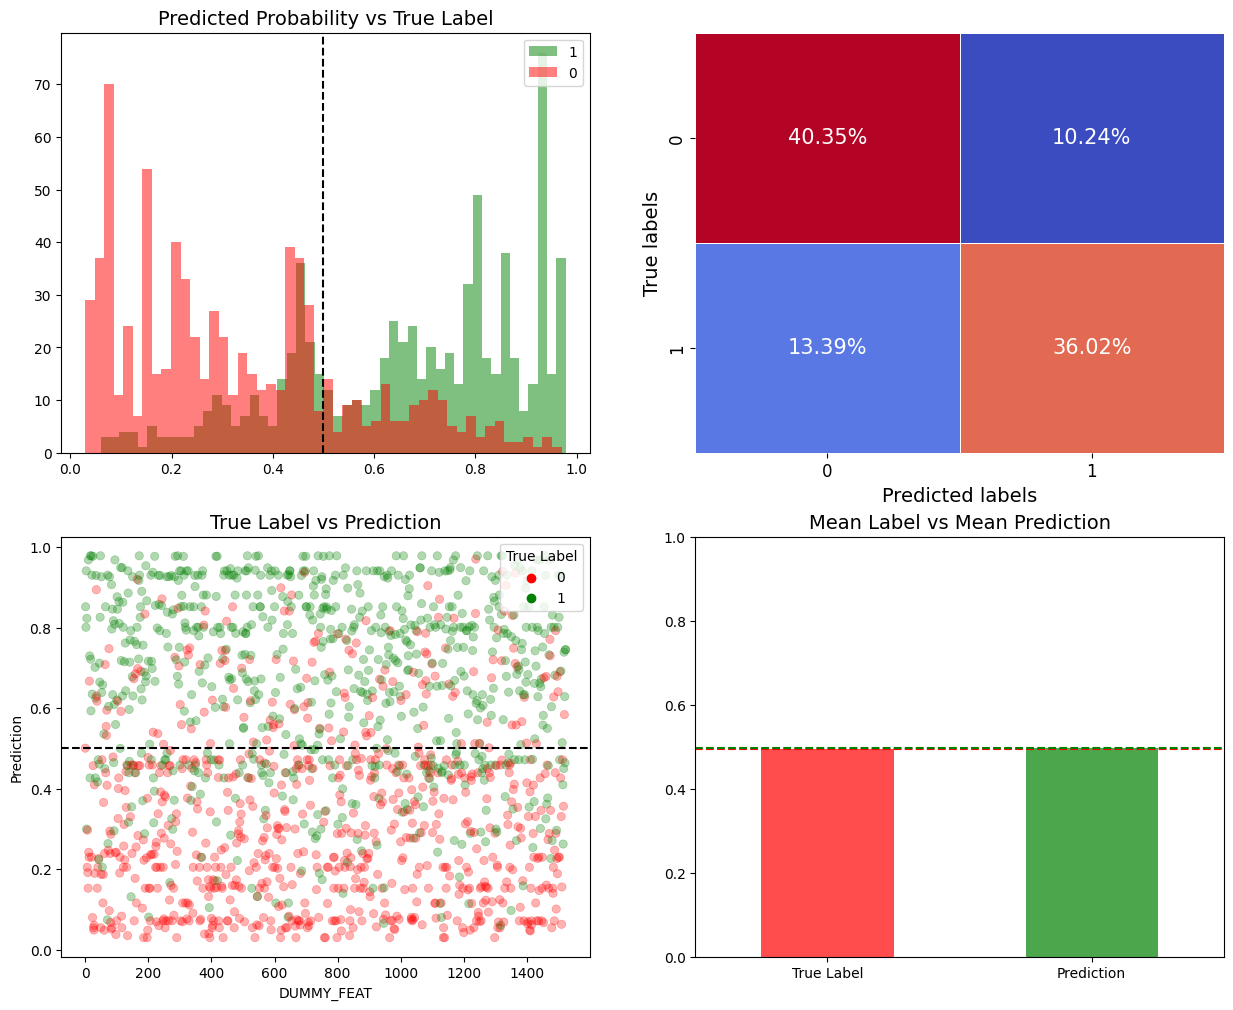

Accuracy score: 	0.7638
AUC ROC: 		0.8505
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       771
           1       0.78      0.73      0.75       753

    accuracy                           0.76      1524
   macro avg       0.76      0.76      0.76      1524
weighted avg       0.76      0.76      0.76      1524

Test score: 0.1509298358543617


The feature delta_Seed is not in the provided data, it will be ignored


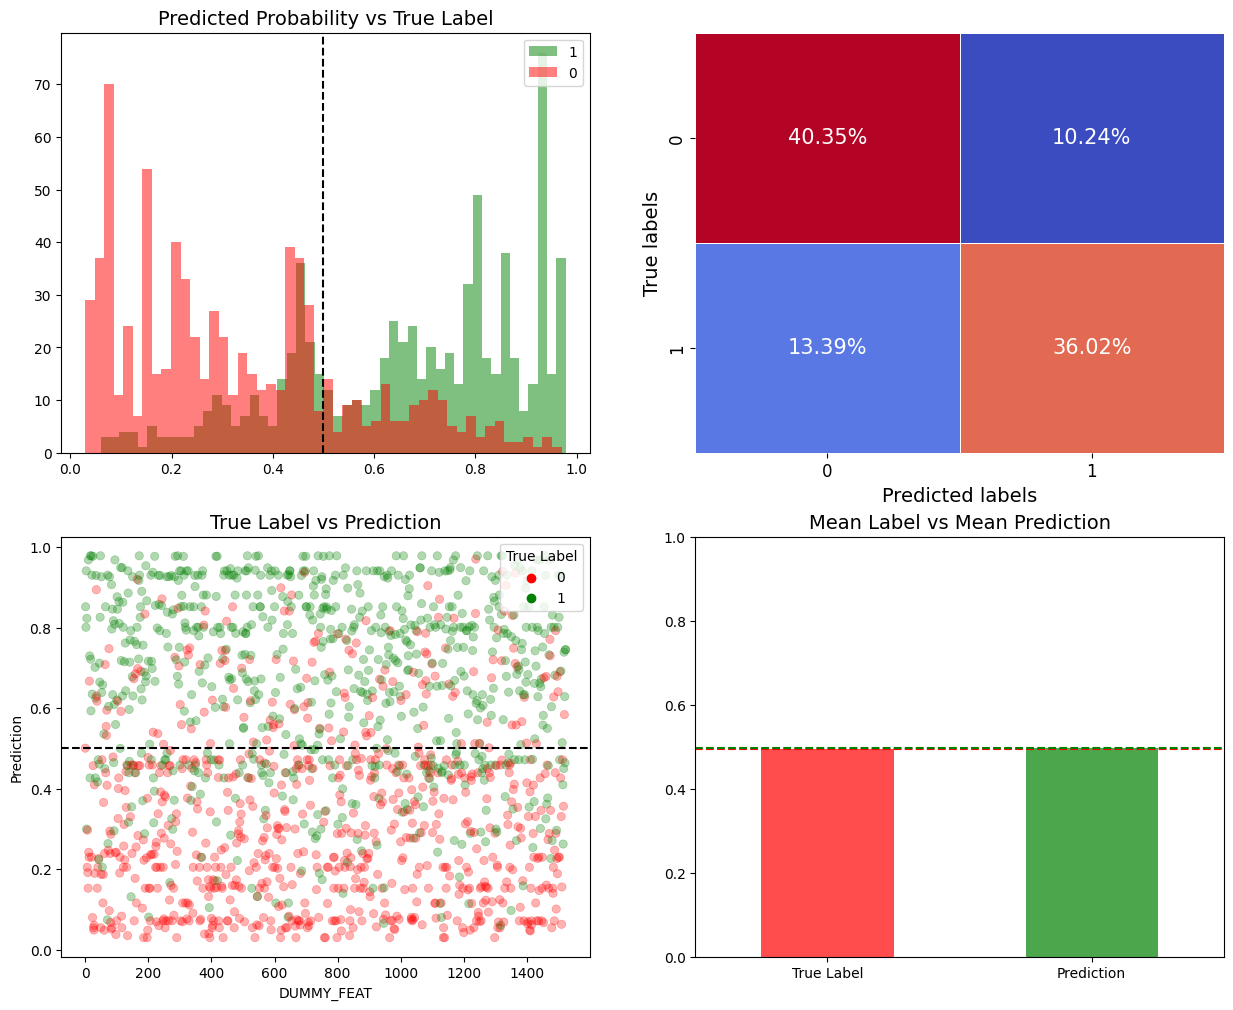

Accuracy score: 	0.7638
AUC ROC: 		0.8505
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       771
           1       0.78      0.73      0.75       753

    accuracy                           0.76      1524
   macro avg       0.76      0.76      0.76      1524
weighted avg       0.76      0.76      0.76      1524

Accuracy train: 		 0.7638
Accuracy test: 			 0.7775
Logloss train: 			 0.4821
Logloss test: 			 0.464
Brier train: 			 0.1585
Brier test: 			 0.1509
Unsure train: 			 21.5223%
Unsure test: 			 23.0366%


,acc_oof,acc_test,logloss_oof,logloss_test,unsure_oof,unsure_test,brier_oof,brier_test
0,0.7638,0.7775,0.4821,0.464,21.5223,23.0366,0.1585,0.1509


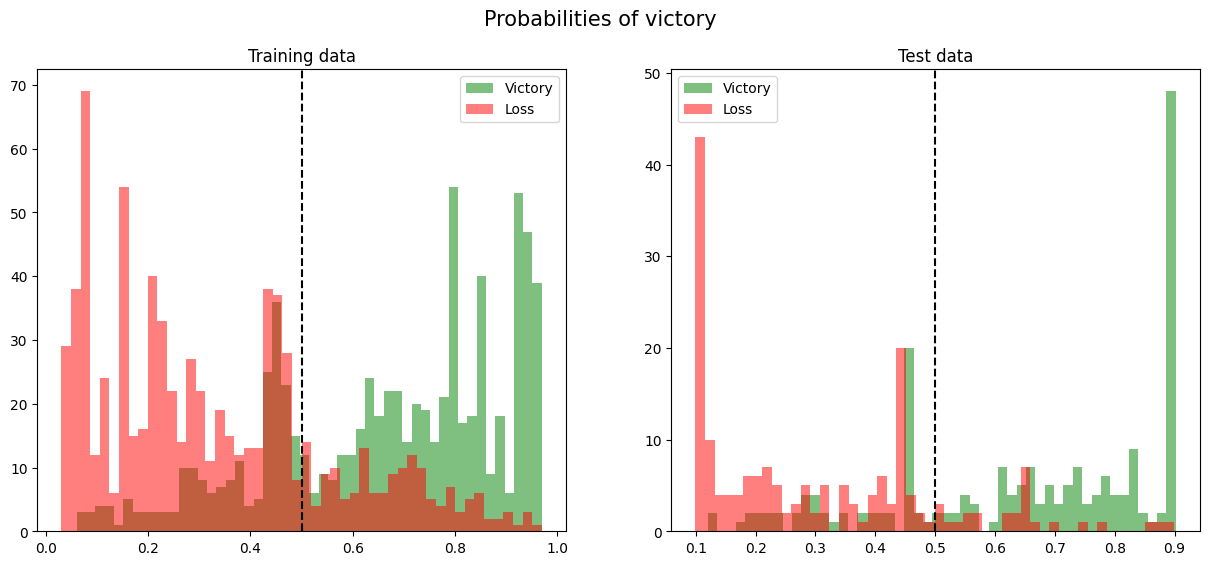

In [24]:
target = df_train["target"]


FEATURES = [c for c in df_train if c not in DROP]
train = df_train[FEATURES].copy()
test_target = df_test["target"]
test = df_test[FEATURES].copy()

train = pred_per_stage(train)
test = pred_per_stage(test)

model = lgb.LGBMClassifier(random_state=34, n_jobs=-1, verbose=-1, n_estimators=10000,
                               learning_rate=0.1,
                            #  colsample_bytree=0.817,
                            #  min_child_weight=5.62,
                            #  reg_lambda=14.72,
                            #  reg_alpha=2.16,
                            #  subsample=0.722,
                            #  num_leaves=66,
                            #  max_depth=95,
                             eval_metric="auc")

pipe = Pipeline([
                ("imp", tml.DfImputer()),
                ("model", model)])

callbacks = [lgb.early_stopping(1000, verbose=0)]
    
fit_params = {"callbacks":callbacks, "eval_metric": "auc"}


oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=True, result_compare=None)


report_victory(y_train=target, y_test=test_target, oof=oof, preds=pred)

# How certain are they

In [25]:
for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb"]:
    df_train[f"{model}_certain"] = np.where((df_train[f"{model}_pred"] > 0.8) | ((df_train[f"{model}_pred"] < 0.2)), 1, 0)
    df_test[f"{model}_certain"] = np.where((df_test[f"{model}_pred"] > 0.8) | ((df_test[f"{model}_pred"] < 0.2)), 1, 0)

In [26]:
df_train["tot_certain"] = df_train[[c for c in df_train if "certain" in c]].sum(axis=1)
df_test["tot_certain"] = df_test[[c for c in df_test if "certain" in c]].sum(axis=1)

In [27]:
df_test[["tot_certain"]].describe()

,tot_certain
count,382.000000
mean,3.764398
std,3.184112
min,0.000000
25%,0.000000
50%,5.000000
75%,7.000000
max,7.000000


In [28]:
tmp_train = df_train[df_train["tot_certain"] >= 5].copy()
tmp_test = df_test[df_test["tot_certain"] >= 5].copy()
for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb", "mean"]:
    print(model)
    print("Before")
    print(brier_score_loss(y_true=tmp_train["target"], y_prob=tmp_train[f'{model}_pred']))
    print(brier_score_loss(y_true=tmp_test["target"], y_prob=tmp_test[f'{model}_pred']))
    print("After")
    tmp_train.loc[tmp_train[f"{model}_pred"] > 0.5, f"{model}_pred"] = 0.99
    tmp_train.loc[tmp_train[f"{model}_pred"] < 0.5, f"{model}_pred"] = 0.01
    tmp_test.loc[tmp_test[f"{model}_pred"] > 0.5, f"{model}_pred"] = 0.99
    tmp_test.loc[tmp_test[f"{model}_pred"] < 0.5, f"{model}_pred"] = 0.01
    print(brier_score_loss(y_true=tmp_train["target"], y_prob=tmp_train[f'{model}_pred']))
    print(brier_score_loss(y_true=tmp_test["target"], y_prob=tmp_test[f'{model}_pred']))

lasso
Before
0.06243948899204741
0.06481107797486767
After
0.07168034528552457
0.07082164948453608
lgb_class
Before
0.06619858988611457
0.06573527551909963
After
0.07168034528552457
0.07082164948453608
lgb
Before
0.06565406934800354
0.0673153380792342
After
0.07168034528552457
0.07082164948453608
logit
Before
0.06335158928477443
0.06749451814919187
After
0.07168034528552457
0.07082164948453608
ridge
Before
0.06635498926788194
0.06778993877079605
After
0.07168034528552457
0.07082164948453608
xgb_class
Before
0.06648720279227649
0.06819123908153674
After
0.07168034528552457
0.07082164948453608
xgb
Before
0.07903905233828537
0.07883564497967725
After
0.07168034528552457
0.07082164948453608
mean
Before
0.0625192153176515
0.06581416298219828
After
0.07168034528552457
0.07082164948453608


# Better mean

In [29]:
to_use = []

for model in ["lasso", "logit", "ridge", "lgb", "lgb_class", "xgb_class", "xgb"]:
    to_use.append(f"{model}_pred")
    df_train["mean_pred"] = df_train[to_use].mean(axis=1)
    df_test["mean_pred"] = df_test[to_use].mean(axis=1)
    print(to_use)
    print(brier_score_loss(y_true=df_train["target"], y_prob=df_train[f'mean_pred']))
    print(brier_score_loss(y_true=df_test["target"], y_prob=df_test[f'mean_pred']))

['lasso_pred']
0.13930602509216833
0.13328711097856336
['lasso_pred', 'logit_pred']
0.13820307773912835
0.13146019482950233
['lasso_pred', 'logit_pred', 'ridge_pred']
0.13858967882380038
0.13180218279636277
['lasso_pred', 'logit_pred', 'ridge_pred', 'lgb_pred']
0.1387217889307824
0.13265964639897887
['lasso_pred', 'logit_pred', 'ridge_pred', 'lgb_pred', 'lgb_class_pred']
0.13861851387602447
0.13332701612431627
['lasso_pred', 'logit_pred', 'ridge_pred', 'lgb_pred', 'lgb_class_pred', 'xgb_class_pred']
0.13931670716879263
0.13441812421368282
['lasso_pred', 'logit_pred', 'ridge_pred', 'lgb_pred', 'lgb_class_pred', 'xgb_class_pred', 'xgb_pred']
0.1400959178990801
0.13541212317838144


# Max pred

In [32]:
df_train["max_pred"] = df_train["mean_pred"]
df_train.loc[df_train["mean_pred"] > 0.8, "max_pred"] = df_train[[f"{model}_pred" for model in ["ridge", "logit", "lasso", "lgb", "xgb", "lgb_class", "xgb_class"]]].max(axis=1)
df_train.loc[df_train["mean_pred"] < 0.2, "max_pred"] = df_train[[f"{model}_pred" for model in ["ridge", "logit", "lasso", "lgb", "xgb", "lgb_class", "xgb_class"]]].min(axis=1)

brier_score_loss(y_true=df_train["target"], y_prob=df_train[f'max_pred'])

0.14016597239382517

# By year evaluation

In [33]:
class ClassifierModel():
    def __init__(self, pipeline, train_data, test_data, train_target, cv, fit_params=None, early_stopping=False):
        self.pipe = pipeline
        self.train_data = train_data
        self.test_data = test_data
        self.train_target = train_target
        self.cv = cv
        self.fit_params = fit_params
        self.early_stopping = early_stopping

    def fit(self, X=None, y=None):
        cv_score = tml.CrossValidate(data=self.train_data, target=self.train_target, test=self.test_data,
                                 estimator=self.pipe, cv=self.cv, fit_params=self.fit_params,
                                 predict_proba=True,
                                 early_stopping=self.early_stopping, regression=False)

        self.oof, self.pred, _ = cv_score.score()

        return self

    def predict(self, X=None, y=None):
        return self.pred

    
class RegressorModel():
    def __init__(self, pipeline, train_data, test_data, train_target, cv, cutoff, padding, fit_params=None, early_stopping=False):
        self.pipe = pipeline
        self.train_data = train_data
        self.test_data = test_data
        self.train_target = train_target
        self.cv = cv
        self.fit_params = fit_params
        self.early_stopping = early_stopping
        self.cutoff = cutoff
        self.padding = padding

    def fit(self, X=None, y=None):
        cv_score = tml.CrossValidate(data=self.train_data, target=self.train_target, test=self.test_data,
                                 estimator=self.pipe, cv=self.cv, fit_params=self.fit_params,
                                 early_stopping=self.early_stopping, regression=True)

        point_oof, point_pred, _ = cv_score.score()

        self.oof, self.pred = _point_to_proba(oof=point_oof, y_train=self.train_target,
                                    preds=point_pred, clip_val=self.cutoff, padd=self.padding)

        return self

    def predict(self, X=None):
        return self.pred

In [34]:
DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]

In [35]:
df = pd.read_csv("data/processed/women_training.csv")

In [39]:
N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

In [40]:
lasso_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Lasso(random_state=34, alpha=0.1, max_iter=10000))])

lasso_not_imp = [
 'delta_def_edge',
 'delta_OT_win',
 'delta_FGM',
 'delta_Ast_TO_ratio',
 'delta_OT_win_perc',
 'delta_FTA_diff',
 'delta_DR',
 'delta_opp_FTA',
 'delta_quality',
 'delta_Ast_diff',
 'delta_FTA',
 'delta_FTM',
 'delta_FTM_diff',
 'delta_DR_diff',
 'delta_Opp_eff_shooting_perc',
 'delta_Eff_shooting_perc',
 'delta_Ast',
 'delta_True_shooting_perc',
 'delta_TO',
 'delta_Stl',
 'delta_Score',
 'delta_PF_diff',
 'delta_OR',
 'delta_TO_diff',
 'delta_TO_perposs_diff',
 'delta_TO_perposs',
 'delta_off_rating_diff',
 'delta_opp_FGA',
 'delta_FGA3',
 'delta_opp_FGM',
 'delta_Tot_Reb_diff',
 'delta_True_shooting_perc_diff',
 'delta_def_rating',
 'delta_Tot_Reb',
 'delta_FGM3_diff',
 'delta_FGM3',
 'delta_FGA_diff',
 'delta_FGA3_diff',
 'delta_opp_score',
 'delta_possessions',
 'delta_opp_TO',
 'delta_opp_possessions',
 'delta_FG3_ratio',
 'delta_Eff_FG_perc_diff',
 'delta_FGA',
 'delta_FGA2',
 'delta_shtg_opportunity',
 'delta_FGA2_diff',
 'delta_FGM_no_ast_perc',
 'delta_FGM_perc']

lasso_feat = [c for c in df if "delta" in c and c not in DROP and c not in lasso_not_imp]

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season != year].copy()
    test = df[df.Season == year].copy()

    lasso = RegressorModel(pipeline=lasso_pipe,
                            train_data=train[lasso_feat],
                            test_data=test[lasso_feat],
                            train_target=train["target_points"],
                            cv=kfolds, cutoff=28, padding=0.01)

    lasso.fit()

    pred = lasso.predict()
    oof = lasso.oof

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))


2022
0.13568849628333726
0.15570875922357172
2023
0.13544179159103983
0.16592500120778875
2024
0.13912560285684783
0.12425701930907504
2025
0.13991362227656126
0.10456883786477485


In [41]:
model = LogisticRegression(C=0.95, random_state=34, max_iter=10000, n_jobs=-1)

logit_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", model)])

logit_not_imp = ['delta_FGM2',
 'delta_Ast',
 'delta_Score',
 'delta_off_edge',
 'delta_opp_FGA'
 'delta_FGM_perc',
 'delta_FGM_no_ast_diff',
 'delta_TO_perposs_diff',
 'delta_Blk',
 'delta_Opp_eff_shooting_perc',
 'delta_PF',
 'delta_Tot_Reb_diff',
 'delta_off_rating_diff',
 'delta_opp_score',
 'delta_off_rating',
 'delta_opp_possessions',
 'delta_possessions',
 'delta_Tot_Reb',
 'delta_Eff_shooting_perc',
 'delta_def_edge',
 'delta_FGM',
 'delta_quality',
 'delta_possessions_diff',
 'delta_FGM3_diff',
 'delta_Stl_diff']

logit_feat = [c for c in df if c not in DROP and c not in logit_not_imp]

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season != year].copy()
    test = df[df.Season == year].copy()

    logit = ClassifierModel(pipeline=logit_pipe,
                            train_data=train[logit_feat],
                            test_data=test[logit_feat],
                            train_target=train["target"],
                            cv=kfolds)

    logit.fit()

    pred = logit.predict()
    oof = logit.oof

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))

2022
0.1471922921805917
0.18881131587425037
2023
0.14729370875777473
0.19213637562046565
2024
0.15104156015017545
0.1321028225073151
2025
0.15324591987418665
0.11552305613840148


In [42]:
model = LogisticRegression(C=0.95, random_state=34, max_iter=10000, n_jobs=-1)

logit_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", model)])


lasso_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Lasso(random_state=34, alpha=0.1, max_iter=10000))])

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season < year].copy()
    test = df[df.Season == year].copy()

    logit = ClassifierModel(pipeline=logit_pipe,
                            train_data=train[logit_feat],
                            test_data=test[logit_feat],
                            train_target=train["target"],
                            cv=kfolds)

    logit.fit()

    pred_logit = logit.predict()
    oof_logit = logit.oof

    lasso = RegressorModel(pipeline=lasso_pipe,
                            train_data=train[lasso_feat],
                            test_data=test[lasso_feat],
                            train_target=train["target_points"],
                            cv=kfolds, cutoff=28, padding=0.01)

    lasso.fit()

    pred_lasso = lasso.predict()
    oof_lasso = lasso.oof

    oof = (oof_logit  + oof_lasso) / 2
    pred = (pred_logit  + pred_lasso) / 2

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))

2022
0.14107967792695963
0.1696043761118759
2023
0.14337665178399142
0.17286031178692587
2024
0.1444316517008153
0.1290411122778062
2025
0.144254330890367
0.10734525196898746
